<h1 style="color:red; text-align:center">
    Projet de machine learning :
    <br>
    -
    <br>
    Classification de la qualité du vin
</h1>

---
**INTRODUCTION**

Dans le cadre de ce projet, nous exploitons des données issues du dépôt **UC Irvine (UCI Machine Learning Repository)**. Deux jeux de données (red et white) y sont mis à disposition pour étudier la qualité du vin à partir de ses caractéristiques physico-chimiques, notamment ::

- **la teneur en acidité des vins**
- **la densité des vins**
- **le pH des vins**
- ...

L'objectif principal est de modéliser la variable cible `quality`, dont les scores s'étendent de 5 à 9. Pour maximiser la pertinence de nos modèles, nous formulons cet enjeu sous la forme d'un problème de **classification binaire** : un vin est considéré de "haute qualité" dès lors que sa note est **supérieure ou égale à 7**.

<u>Les différentes étapes de notre projet seront les suivantes :</u> 

1. **Consolidation du dateset**
2. **Analyse exploratoire des données (EDA)**
3. **Développement des modèles**
4. **Evaluation des modèles**
5. **Optimisation des hyperparamètres**

---

<h2 style="font-weight:bolder">I) Import des librairies</h2>

In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h2 style="font-weight:bolder">II) Consolidation du dataset</h2>

Cette phase est très importante car c'est ce qui nous permettra de développer notre modèle après avoir réaliser une analyse exploratoire des données. Concrètement la consolidation du dataset revient à concatener les données du dataset `red` et `white`, car les variables sont les mêmes mais la couleur du vin change.

L'idée ici est donc pour chacun des datasets d'ajouter une colonne `color` puis de faire une concaténation des colonnes afin d'avoir notre dataset centralisée.

<h3 style="font-weight:bolder; color:blue">2.1) Liste des sources de données</h3>

In [3]:
os.listdir("./data")

['winequality-red.csv', 'winequality-white.csv', 'winequality.names']

<h3 style="font-weight:bolder; color:blue">2.2) Chargement du dataset <code>"df_red"</code></h3>

In [4]:
df_red = pd.read_csv("data/winequality-red.csv", sep=";")

<h4 style="color:green">2.2.1) Ajout de la colonne <code>"color"</code></h4>

In [5]:
df_red["color"] = "red"

In [6]:
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


<h3 style="font-weight:bolder; color:blue">2.3) Chargement du dataset <code>"df_white"</code></h3>

In [7]:
df_white = pd.read_csv("data/winequality-white.csv", sep=";")

<h4 style="color:green">2.3.1) Ajout de la colonne <code>"color"</code></h4>

In [8]:
df_white["color"] = "white"

In [9]:
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


<h3 style="font-weight:bolder; color:blue">2.4) Cohérence du nombre d'occurences</code></h3>

Ici nous calculons la somme du nombre d'occurence des datasets `red` et `white` avec la méthode `df.shape` avons concaténation afin de voir si cette somme sera la même après concaténation, c'est une étape de validation des données.

In [10]:
df_white.shape[0] + df_red.shape[0] # [0] pour récuperer le nombre de ligne

6497

<h3 style="font-weight:bolder; color:blue">2.5) Concaténation des datasets <code>"df_red"</code> X <code>"df_white"</code></h3>

Nous allons maintenant concatener nos datasets en un `dataframe` avec la méthode `pd.concat()` dans lequel toutes les prochaines étapes de transformations et de développement des modèles seront réalisés.

In [11]:
df = pd.concat([df_red, df_white], axis=0) # axis 0 pour concatener df_red "en dessous" de df_white

<h2 style="font-weight:bolder">III) Analyse Exploratoire des Données (EDA)</h2>

---
L'analyse exploratoire constitue une étape primordiale : elle permet d'appréhender la structure du jeu de données et d'orienter les choix de prétraitement requis pour optimiser la performance des modèles.

Toutes les variables fournies par la base **UC Irvine** étant de nature quantitative continue, l'enjeu principal réside dans l'étude fine de leurs distributions. Cette analyse vise notamment à :

- Identifier la forme des distributions
- Évaluer le besoin de transformations
- Analyser le déséquilibre de la variable cible
- Mesurer la corrélation entre les variables
---

À l'aide des méthodes `df.head()` et `df.tail()` nous allons afficher les 5 premières et dernières ligne de notre dataset afin de voir si la variable color a bien été concatener "en-dessous", avec les red au début de notre dataset et les white à la fin.

In [12]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [13]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
4897,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white


<h3 style="font-weight:bolder; color:blue">3.1) Dimensions du Dataset</h3>

Nous constatons ici les dimensions de notre dataset sont cohérentes avec le calcul effectué précédemment, nous avons bien 6497 lignes après concaténation.

In [14]:
df.shape

(6497, 13)

<h3 style="font-weight:bolder; color:blue">3.2) Informations du dataset</h3>

Afin d'avoir plus d'informations concernant notre dataset nous allons utiliser la méthode `df.info()` permettant de pouvoir visualiser :

1. **Index des colonnes**
2. **Noms des colonnes**
3. **Nombre de valeurs non nulles**
4. **Types de nos variables**

Après utilisation nous voyons que nous avons 13 variables et que 11 d'entre elles sont quantitatives et les variables `quality` et `color` sont qualitatives.

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 710.6 KB


<h3 style="font-weight:bolder; color:blue">3.1) Description des données</h3>

La méthode `df.describe()` est particulièrement utile pour obtenir une vision synthétique des propriétés statistiques de chaque variable. Elle fournit un premier aperçu de :

- **la dispertion des données avec l'écart-type**
- **l'échelle des données avec le min et max**
- **l'existence d'outliers en observant l'écart en le 75% percentile et la valeur max**

In [16]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [17]:
df["color"].value_counts(normalize=True)

color
white    0.753886
red      0.246114
Name: proportion, dtype: float64

In [18]:
df["quality"].value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

In [19]:
df["quality"] = np.where(df["quality"].between(7, 9), "1", "0")

Text(0.5, 0, 'qualité du vin')

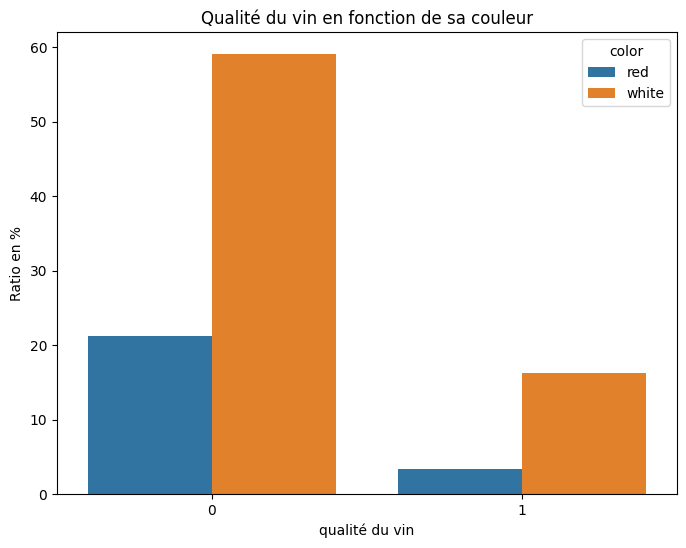

In [20]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="quality",
    hue="color",
    stat="percent"
)

plt.title("Qualité du vin en fonction de sa couleur")
plt.ylabel("Ratio en %")
plt.xlabel("qualité du vin")

In [22]:
#Continuiter de l4EDA

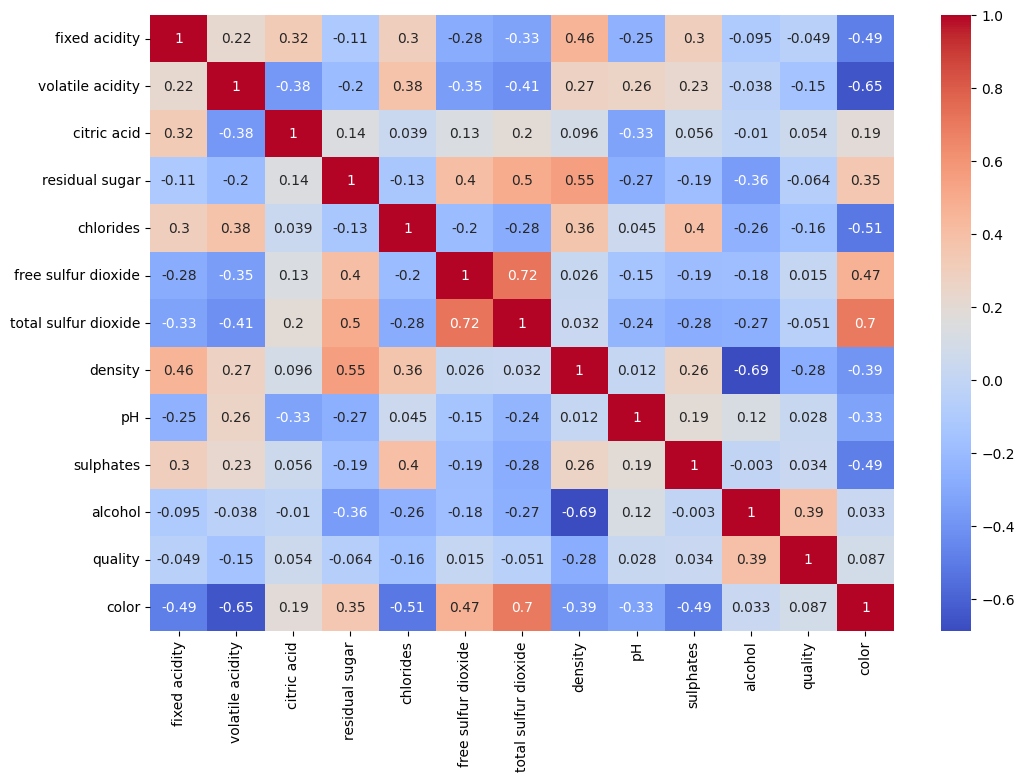

In [21]:
df_corr = df.copy()
df_corr["color"] = df_corr["color"].map({"red": 0, "white": 1})
df_corr["quality"] = df_corr["quality"].astype(int)

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm")
plt.show()